In [1]:
from datasets import load_dataset, DatasetDict

hf_nature_ds = load_dataset("mertcobanov/nature-dataset")
split = hf_nature_ds["train"].train_test_split(test_size=0.4, seed=42)
hf_nature_unseperated_ds = DatasetDict({
    "train": split["train"],
    "validation\test": split["test"]
})
validation_test_split = hf_nature_unseperated_ds["validation\test"].train_test_split(test_size=0.5, seed=42)
hf_nature_ds = DatasetDict({
    "train": hf_nature_unseperated_ds["train"],
    "validation": validation_test_split["train"],
    "test": validation_test_split["test"]
})
hf_nature_ds

/home/debangshup/miniconda3/envs/ML_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'caption'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'caption'],
        num_rows: 10000
    })
})

In [2]:
from datasets import load_dataset, DatasetDict
import re

NON_TRAVERSIBLE_SUBJECTS = {
    # Water bodies
    "ocean", "lake", "river", "flood", "lava", "quicksand",
    "glacier", "chasm", "sea", "waterfall", "pond", "stream",
    "brook", "creek", "reservoir", "lagoon", "bay", "gulf",
    "inlet", "estuary", "delta", "fjord", "strait", "channel",
    "rapids", "cascade", "torrent", "whirlpool", "tide", "surf",
    "wave", "tsunami", "puddle", "marsh", "bog", "fen", "mire",
    "quagmire", "swamp", "wetland", "floodplain", "moat",
    # Drops & hazardous elevation
    "cliff", "ravine", "gorge", "canyon", "precipice", "abyss",
    "crevasse", "crevice", "fissure", "crater", "pit", "sinkhole",
    "escarpment", "bluff", "ledge", "overhang", "scarp", "dropoff",
    "chute", "gulch", "gully", "trench", "void", "shaft",
    # Dense vegetation
    "thicket", "bramble", "undergrowth", "briars", "thorns",
    "scrub", "brush", "tangle", "briar", "nettle", "shrub",
    "hedge", "canopy", "jungle", "rainforest", "mangrove",
    "bracken", "fern", "sedge", "reed", "bulrush",
    # Unstable ground
    "mud", "lava", "magma", "ash", "scree", "talus", "gravel",
    "rubble", "debris", "landslide", "avalanche", "rockfall",
    "mudslide", "erosion", "subsidence",
    # Structures & barriers
    "wall", "fence", "barrier", "barricade", "dam", "weir",
    "embankment", "levee", "dyke", "rampart", "fortification",
}

TRAVERSIBLE_INDICATORS = {
    # Paths & trails
    "path", "trail", "track", "route", "walkway", "footpath",
    "towpath", "bridleway", "byway", "lane", "alley", "passage",
    "corridor", "shortcut", "detour", "circuit", "loop",
    # Roads & paved surfaces
    "road", "street", "avenue", "boulevard", "highway", "motorway",
    "freeway", "expressway", "carriageway", "driveway", "pavement",
    "sidewalk", "tarmac", "asphalt", "cobblestone", "flagstone",
    "paving", "causeway", "thoroughfare", "beltway", "turnpike",
    # Crossings & connections
    "bridge", "overpass", "underpass", "viaduct", "flyover",
    "crossing", "ford", "stepping", "jetty", "pier",
    "pontoon", "gangway", "ramp", "junction", "interchange",
    # Vertical traversal
    "steps", "stairs", "stairway", "staircase", "ladder", "ramp",
    "slope", "gradient", "ascent", "descent", "incline", "decline",
    # Open traversible terrain
    "meadow", "field", "plain", "plateau", "clearing", "glade",
    "lawn", "grassland", "pasture", "paddock", "common", "heath",
    "moor", "tundra", "savanna", "prairie", "steppe", "flat",
    # Marked routes
    "waypoint", "marker", "signpost", "waymarked", "blazed",
    "mapped", "designated", "maintained", "groomed", "paved",
}

CONDITIONAL_BLOCKERS = {
    # Weather & surface conditions
    "water", "steep", "snow", "ice", "frost", "sleet", "hail",
    "frozen", "slippery", "icy", "wet", "waterlogged", "sodden",
    # Terrain descriptors
    "rocky", "dense", "overgrown", "rugged", "rough", "uneven",
    "jagged", "boulder", "boulders", "stony", "loose", "unstable",
    "crumbling", "eroded", "washed",
    # Vegetation density
    "forested", "wooded", "bushy", "tangled", "matted", "thick",
    # Elevation & gradient
    "mountain", "mountainous", "highland", "upland", "alpine",
    "vertical", "sheer", "exposed",
}

def label_traversibility(example):
    caption = example["caption"].lower()
    words = set(re.findall(r'\b\w+\b', caption))

    has_traversible = bool(words & TRAVERSIBLE_INDICATORS)
    has_hard_blocker = bool(words & NON_TRAVERSIBLE_SUBJECTS)
    has_conditional = bool(words & CONDITIONAL_BLOCKERS)

    is_not_traversible = has_hard_blocker or (has_conditional and not has_traversible)
    return {"label": 0 if is_not_traversible else 1}

hf_nature_ds = hf_nature_ds.map(label_traversibility)
hf_nature_ds = hf_nature_ds.remove_columns("caption")
hf_nature_ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 30000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

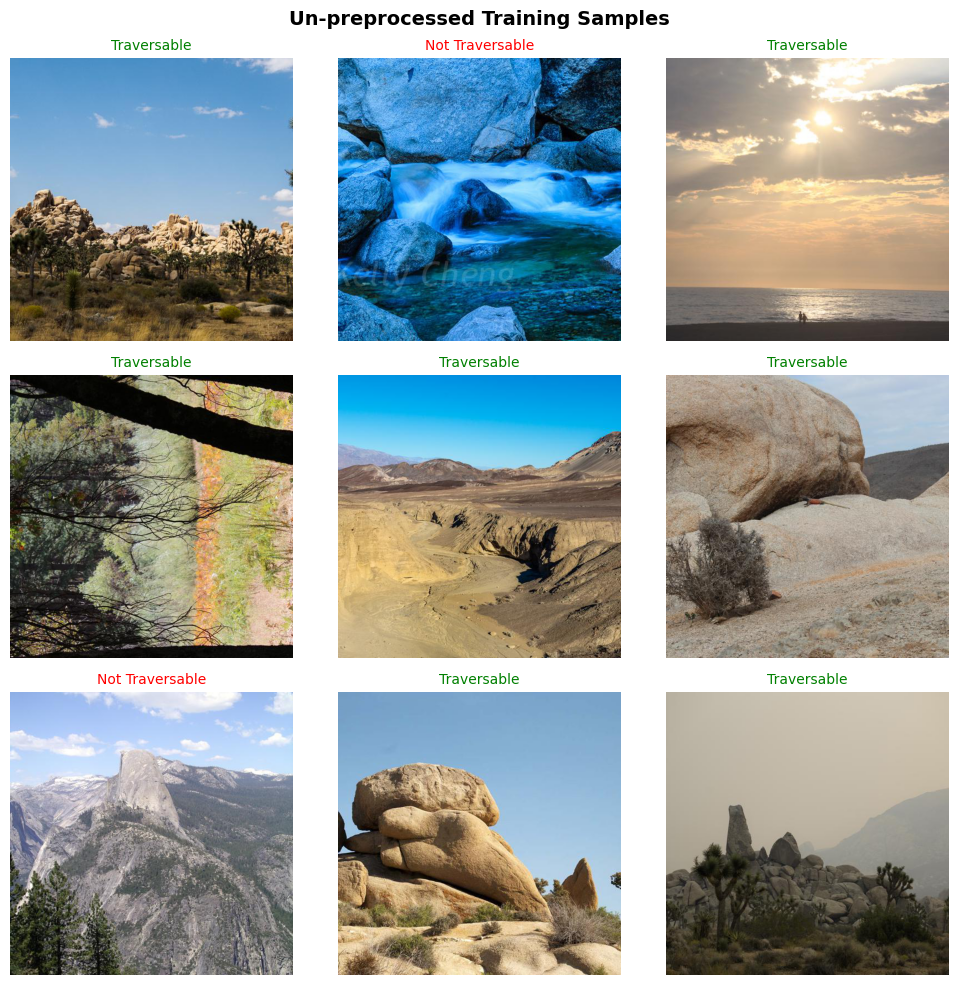

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training_samples(dataset, num_samples=9, cols=3):
    rows = num_samples // cols
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    fig.suptitle("Un-preprocessed Training Samples", fontsize=14, fontweight="bold")

    # Grab a batch of samples
    samples = dataset["train"].shuffle(seed=42).select(range(num_samples))

    for i, example in enumerate(samples):
        ax = axes[i // cols, i % cols]

        image = np.array(example["image"])
        label = example["label"]
        label_name = "Traversable" if label == 1 else "Not Traversable"

        # Squeeze grayscale channel dim (92, 92, 1) → (92, 92)
        ax.imshow(image.squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(label_name, fontsize=10,
                     color="green" if label == 1 else "red")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("training_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_samples(hf_nature_ds)

In [4]:
import os
import tensorflow as tf
from tensorflow.data import Dataset as TFDataset
num_cpus = os.cpu_count() if os.cpu_count() is not None else 1
# Now, split into training and validation tensorflow datasets
train_nature_ds: TFDataset = hf_nature_ds["train"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=True
)
validation_nature_ds: TFDataset = hf_nature_ds["validation"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
test_nature_ds: TFDataset = hf_nature_ds["test"].to_tf_dataset(
    columns="image",
    label_cols="label",
    batch_size=32,
    shuffle=False
)
train_nature_ds, validation_nature_ds, test_nature_ds

2026-04-01 14:32:49.818896: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 14:32:50.251659: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-01 14:32:51.527074: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 14:32:52.380617: E external/local_xla/xla/stream_executor

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 512, 512, 3), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

In [5]:
import numpy as np
import tensorflow as tf # Ensure tf is imported for tf.cast

def preprocess(image, label):
    # Convert to grayscale (H, W, 1)
    image = tf.image.rgb_to_grayscale(image)
    # Resize to (96, 96)
    image = tf.image.resize(image, (96, 96))
    # Cast to uint8 for space
    image = tf.cast(image, tf.float32) / 255.0
    # label shape = (32, 1)
    return image, label

# Apply preprocess to individual images, then batch and prefetch
train_nature_ds = train_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
validation_nature_ds = validation_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)
test_nature_ds = test_nature_ds.map(preprocess).prefetch(tf.data.AUTOTUNE)

# Expand labels to leave TensorSpec(shape=(None, )) to TensorSpec(shape=(None, 1)), allowing for tensorflow metrics
def expand_labels(image, label):
    label = tf.expand_dims(label, axis=-1)
    return image, label

train_nature_ds = train_nature_ds.map(expand_labels)
validation_nature_ds = validation_nature_ds.map(expand_labels)
test_nature_ds = test_nature_ds.map(expand_labels)

train_nature_ds, validation_nature_ds, test_nature_ds

(<_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>,
 <_MapDataset element_spec=(TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>)

In [6]:
image, label = next(iter(train_nature_ds))

image.shape

2026-04-01 14:32:53.457943: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 201326848 bytes after encountering the first element of size 201326848 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


TensorShape([32, 96, 96, 1])

In [7]:
num_traversible, num_not_traversible = 0, 0
images_traversed = 0
for(image, label) in train_nature_ds.unbatch():
    if label == 1:
        num_traversible += 1
    else:
        num_not_traversible += 1
    images_traversed += 1
    if(images_traversed % 1000 == 0):
      print(f"Processed {images_traversed}")
num_traversible, num_not_traversible

Processed 1000
Processed 2000
Processed 3000
Processed 4000
Processed 5000
Processed 6000
Processed 7000
Processed 8000
Processed 9000
Processed 10000
Processed 11000
Processed 12000
Processed 13000
Processed 14000
Processed 15000
Processed 16000
Processed 17000
Processed 18000
Processed 19000
Processed 20000
Processed 21000
Processed 22000
Processed 23000
Processed 24000
Processed 25000
Processed 26000
Processed 27000
Processed 28000
Processed 29000
Processed 30000


2026-04-01 14:35:42.228105: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


(15080, 14920)

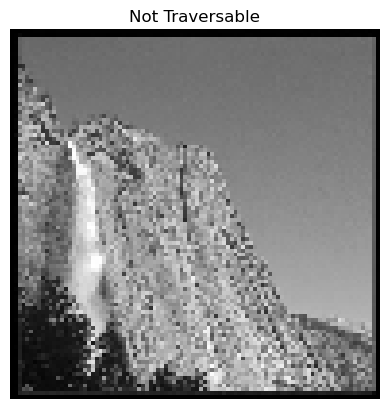

In [8]:
plt.imshow(image.numpy(), cmap="gray")
plt.title("Traversable" if label[0] == 1 else "Not Traversable")
plt.axis("off")
plt.show()

In [9]:
# Verify your dataset is returning correct image-label pairs
for images, labels in train_nature_ds.take(1):
    print("Image shape:", images.shape)   # should be (batch, 92, 92, 3)
    print("Label shape:", labels.shape)   # should be (batch,)
    print("Label values:", labels[:10])   # should be mix of 0s and 1s
    print("Image min/max:", tf.reduce_min(images), tf.reduce_max(images))
    # Image values should be between 0 and 1 — if max is 255 that's your problem

Image shape: (32, 96, 96, 1)
Label shape: (32, 1)
Label values: tf.Tensor(
[[1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]], shape=(10, 1), dtype=int64)
Image min/max: tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(0.99607843, shape=(), dtype=float32)


2026-04-01 14:35:46.575226: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
import tensorflow as tf
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same", input_shape=(96, 96, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    
    tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="TinyVGG")
model.summary()

/home/debangshup/miniconda3/envs/ML_env/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,745 (92.75 KB)

 Trainable params: 23,745 (92.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf

# Compile the model & Run the epochs
EPOCHS: int = 40

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=4,
    verbose=1,
    min_lr=1e-6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"), # of all predicted positives, how many were correct
        tf.keras.metrics.Recall(name="recall"), # of all true positives, how many were predicted
        tf.keras.metrics.AUC(name="auc"), # area under ROC curve 1.0 = perfect, 0.5 = random
        tf.keras.metrics.F1Score(threshold=0.5)
    ]
)

model.fit(
    train_nature_ds,
    validation_data=validation_nature_ds,
    epochs=EPOCHS,
    callbacks=[lr_scheduler]
)

Epoch 1/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 237s 251ms/step - accuracy: 0.5057 - auc: 0.5093 - f1_score: 0.5353 - loss: 0.6931 - precision: 0.5075 - recall: 0.5664 - val_accuracy: 0.5013 - val_auc: 0.5031 - val_f1_score: 4.0088e-04 - val_loss: 0.6932 - val_precision: 1.0000 - val_recall: 2.0048e-04 - learning_rate: 0.0020
Epoch 2/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 234s 249ms/step - accuracy: 0.5034 - auc: 0.5078 - f1_score: 0.5578 - loss: 0.6930 - precision: 0.5049 - recall: 0.6231 - val_accuracy: 0.5386 - val_auc: 0.5434 - val_f1_score: 0.3800 - val_loss: 0.6902 - val_precision: 0.5762 - val_recall: 0.2835 - learning_rate: 0.0020
Epoch 3/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 230s 246ms/step - accuracy: 0.5406 - auc: 0.5587 - f1_score: 0.4931 - loss: 0.6847 - precision: 0.5536 - recall: 0.4445 - val_accuracy: 0.5598 - val_auc: 0.5962 - val_f1_score: 0.3752 - val_loss: 0.6813 - val_precision: 0.6424 - val_recall: 0.2650 - learning_rate: 0.0020
Epoch 4/35
938/938 ━━━━━━━━━━━━━━━━━━━━ 213s 227ms/step 

In [12]:
model.evaluate(test_nature_ds)

313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.6818 - auc: 0.7512 - f1_score: 0.6758 - loss: 0.5894 - precision: 0.6897 - recall: 0.6624


[0.5893934369087219,
 0.6818000078201294,
 0.6896838545799255,
 0.6624051332473755,
 0.7511721849441528,
 array([0.67576927], dtype=float32)]

In [13]:
# Quantize to tf.uint8
converter = tf.lite.TFLiteConverter.from_keras_model(model)

def representative_dataset_gen():
    for images, _ in train_nature_ds.take(100):  # Use a subset of training data for calibration
        # The representative dataset should provide float32 inputs for calibration
        yield [images]

converter.representative_dataset = representative_dataset_gen
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8  # Set input type to uint8
converter.inference_output_type = tf.uint8 # Set output type to uint8

tflite_model = converter.convert()

# Save locally...
with open("tinyvgg_terrain_quantized_uint8_w_head.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Saved Quantized uint8 model size: {len(tflite_model) / 1024:.2f} KB")

INFO:tensorflow:Assets written to: /tmp/tmpau1vsusb/assets


INFO:tensorflow:Assets written to: /tmp/tmpau1vsusb/assets


Saved artifact at '/tmp/tmpau1vsusb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134958076452432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842304080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842306384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842303696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842305808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842301968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842302160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842301584: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/debangshup/miniconda3/envs/ML_env/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775080251.599962  173863 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1775080251.600347  173863 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-01 16:50:51.603017: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpau1vsusb
2026-04-01 16:50:51.604217: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-01 16:50:51.604222: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpau1vsusb
I0000 00:00:1775080251.611396  173863 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-04-01 16:50:51.612068: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
202

Saved Quantized uint8 model size: 30.46 KB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8
2026-04-01 16:51:22.261382: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3705] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [14]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Load the TFLite model
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

Input details: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 96, 96,  1], dtype=int32), 'shape_signature': array([-1, 96, 96,  1], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.0039061899296939373, 0), 'quantization_parameters': {'scales': array([0.00390619], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 20, 'shape': array([1, 1], dtype=int32), 'shape_signature': array([-1,  1], dtype=int32), 'dtype': <class 'numpy.uint8'>, 'quantization': (0.00390625, 0), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([0], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/home/debangshup/miniconda3/envs/ML_env/lib/python3.13/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [15]:
# Helper function to run inference on a single image
def run_tflite_inference(interpreter, input_data):
    # Ensure the input data is in the correct format (uint8 and scaled 0-255)
    # The input_data from test_nature_ds is float32 (0-1), so we need to convert it.
    input_data_int8 = tf.cast(input_data * 255, tf.uint8)

    interpreter.set_tensor(input_details[0]['index'], input_data_int8)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    return output_data

all_predictions = []
all_labels = []

# Iterate over the test dataset and run inference
print("Running inference on test dataset...")
for i, (images, labels) in enumerate(test_nature_ds):
    for j in range(images.shape[0]): # Iterate through batch
        image = images[j:j+1] # Get a single image with batch dimension
        label = labels[j].numpy()

        # Run inference for the single image
        prediction = run_tflite_inference(interpreter, image)

        # Convert output back to float (0-1) and get probability
        # The output from a uint8 quantized model will be uint8 scaled. Scale back to float.
        # This assumes the output activation is sigmoid, mapping to (0, 255) for uint8 output.
        # A typical sigmoid output for uint8 is 0-255, so divide by 255 to get 0-1.
        predicted_probability = prediction.astype(np.float32) / 255.0

        all_predictions.append(predicted_probability[0][0])
        all_labels.append(label[0])

    if (i + 1) % 100 == 0:
        print(f"Processed {i+1} batches of test data.")

print("Inference complete.")

Running inference on test dataset...
Processed 100 batches of test data.
Processed 200 batches of test data.
Processed 300 batches of test data.
Inference complete.


2026-04-01 16:52:12.089376: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
# Convert lists to numpy arrays
all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

# Calculate metrics
# For accuracy, precision, recall, we need binary predictions (0 or 1)
binary_predictions = (all_predictions > 0.5).astype(int)

accuracy = accuracy_score(all_labels, binary_predictions)
precision = precision_score(all_labels, binary_predictions)
recall = recall_score(all_labels, binary_predictions)
auc = roc_auc_score(all_labels, all_predictions)

print(f"Quantized Model Evaluation on Test Dataset:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC: {auc:.4f}")

Quantized Model Evaluation on Test Dataset:
Accuracy: 0.6811
Precision: 0.6848
Recall: 0.6724
AUC: 0.7506


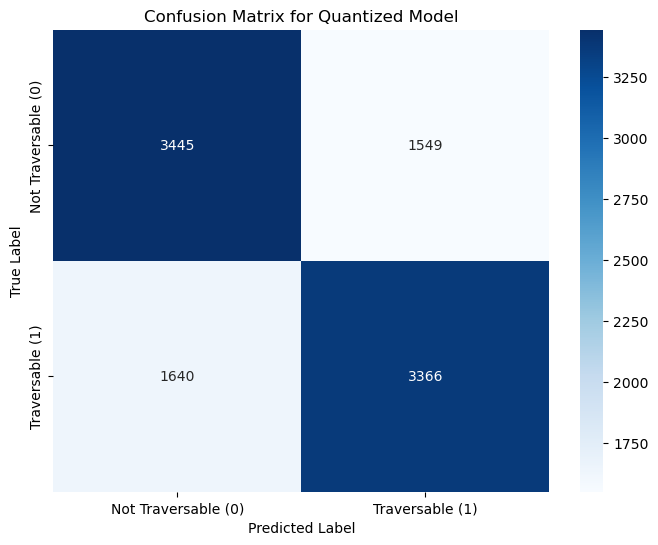

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, binary_predictions)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Traversable (0)', 'Traversable (1)'],
            yticklabels=['Not Traversable (0)', 'Traversable (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Quantized Model')
plt.show()

In [19]:
# Save the model without a head...
model.pop()
model.summary()
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.representative_dataset = representative_dataset_gen
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8  # Set input type to uint8
converter.inference_output_type = tf.uint8 # Set output type to uint8

tflite_model = converter.convert()

# Save locally...
with open("tinyvgg_terrain_quantized_uint8_headless.tflite", "wb") as f:
    f.write(tflite_model)

print(f"Saved Quantized uint8 model size: {len(tflite_model) / 1024:.2f} KB")

Model: "TinyVGG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 96, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,220 (278.21 KB)

 Trainable params: 23,728 (92.69 KB)

 Non-trainable params: 0 (0.00 B)

...

INFO:tensorflow:Assets written to: /tmp/tmpy2l3nolb/assets


INFO:tensorflow:Assets written to: /tmp/tmpy2l3nolb/assets


Saved artifact at '/tmp/tmpy2l3nolb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  134958076452432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842304080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842306384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842303696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842305808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134946842301968: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/debangshup/miniconda3/envs/ML_env/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1775080938.278283  173863 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1775080938.278297  173863 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-01 17:02:18.281980: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpy2l3nolb
2026-04-01 17:02:18.282521: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-01 17:02:18.282528: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpy2l3nolb
2026-04-01 17:02:18.286019: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-01 17:02:18.306263: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle a

KeyboardInterrupt: 